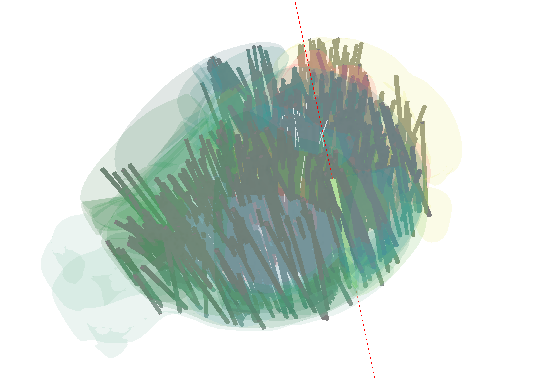

In [ ]:
# Change kernel (on the right-top of Jupyter lab) to 'Python (ibl)'
# Alyx password for "intbrainlab" is: international
# Find an eid: https://viz.internationalbrainlab.org/app?spikesorting=ss_2024-05-06

from pathlib import Path

from one.api import ONE

CACHE_DIR = Path('G:/academic/ONE')
CACHE_DIR.mkdir(parents=True, exist_ok=True)
one = ONE(base_url='https://openalyx.internationalbrainlab.org', cache_dir=CACHE_DIR, mode='remote')

eid0 = 'e5c75b62-6871-4135-b3d0-f6464c2d90c0'  # pid: aac3b928-e99a-4039-ace1-af45d0130d82
trials0 = one.load_object(eid0, 'trials', collection='alf', namespace='ibl')


## Raw data check
The 	rials0 object loaded above is ALF behavioral data, not raw continuous ephys. The session may still contain raw SpikeGLX AP files under aw_ephys_data; the cell below checks for those files without downloading the large binaries.


In [ ]:
from pathlib import PurePosixPath

datasets = one.list_datasets(eid0, details=True, query_type='remote', keep_eid_index=True)
rel = datasets['rel_path'].astype(str)

trials_rows = datasets.loc[rel.str.contains(r'(?:^|/)_(?:ibl_)?trials\.', regex=True), ['rel_path', 'file_size']].copy()
raw_ap_rows = datasets.loc[
    rel.str.contains(r'^raw_ephys_data/probe\d+/', regex=True)
    & rel.str.contains(r'\.ap\.(?:cbin|bin|meta|ch)$', regex=True),
    ['rel_path', 'file_size']
].copy()
raw_ap_rows['file_size_GB'] = raw_ap_rows['file_size'] / 1e9

CURRENT_OBJECT_IS_RAW = False
SESSION_HAS_RAW_AP = len(raw_ap_rows) > 0

print('trials0 type:', type(trials0))
print('Current loaded object is raw continuous ephys:', CURRENT_OBJECT_IS_RAW)
print('Session has raw AP files available:', SESSION_HAS_RAW_AP)
display(raw_ap_rows.sort_values('rel_path'))


## IBL kernel: optional raw AP download and conversion
Run this section in the Python (ibl) kernel. OpenAlyx provides AP raw data for this session as compressed SpikeGLX .ap.cbin files. Kilosort4 should be run on an int16 .ap.bin, so this section can download the .cbin/.meta/.ch files and decompress the selected probe. The default flags are False because each AP file is tens of GB and the decompressed .bin will require additional disk space.


In [ ]:
from pathlib import Path, PurePosixPath
import json

PROBE = 'probe00'
RUN_RAW_DOWNLOAD = True
RUN_CBIN_DECOMPRESS = True

probe_rows = raw_ap_rows[raw_ap_rows['rel_path'].astype(str).str.contains(f'raw_ephys_data/{PROBE}/')].copy()
display(probe_rows.sort_values('rel_path'))

def expected_local_path(rel_path):
    """Return the normal ONE cache path for this relative dataset path."""
    rel_path = PurePosixPath(str(rel_path))
    hits = sorted(CACHE_DIR.glob(f'**/{rel_path.as_posix()}'))
    if hits:
        return hits[0]
    return CACHE_DIR / rel_path

def file_status(path, expected_size=None):
    path = Path(path)
    if not path.exists():
        return {'path': str(path), 'status': 'missing', 'size': 0, 'expected_size': expected_size}
    size = path.stat().st_size
    if expected_size and size == int(expected_size):
        status = 'complete'
    elif expected_size and size < int(expected_size):
        status = 'partial'
    elif expected_size and size > int(expected_size):
        status = 'size_mismatch_large'
    else:
        status = 'exists_unverified'
    return {'path': str(path), 'status': status, 'size': size, 'expected_size': expected_size}

def load_rel_path(eid, rel_path):
    rel_path = PurePosixPath(str(rel_path))
    return Path(one.load_dataset(
        eid,
        rel_path.name,
        collection=str(rel_path.parent),
        query_type='remote',
        download_only=True,
    ))

def ensure_dataset_downloaded(eid, row):
    rel_path = str(row['rel_path'])
    expected_size = int(row['file_size']) if row.get('file_size') else None
    target = expected_local_path(rel_path)
    before = file_status(target, expected_size)

    if before['status'] == 'complete':
        print('already complete:', target)
        return {**before, 'rel_path': rel_path, 'action': 'skipped_complete'}

    if before['status'] == 'partial':
        print('partial file found; continuing download/check:', target, before['size'], '/', expected_size)
    elif before['status'] == 'missing':
        print('missing file; starting download:', rel_path)
    else:
        print('existing file needs verification/redownload:', before)

    path = load_rel_path(eid, rel_path)
    after = file_status(path, expected_size)
    if after['status'] != 'complete':
        print('warning: file is still not complete after download attempt:', after)
    else:
        print('complete:', path)
    return {**after, 'rel_path': rel_path, 'action': 'downloaded_or_resumed', 'before': before}

download_records = []
downloaded_paths = []
if RUN_RAW_DOWNLOAD:
    needed_rows = probe_rows.sort_values('rel_path')
    if needed_rows.empty:
        raise RuntimeError(f'No AP raw files found for {PROBE}')
    for _, row in needed_rows.iterrows():
        record = ensure_dataset_downloaded(eid0, row)
        download_records.append(record)
        downloaded_paths.append(record['path'])
else:
    print('RUN_RAW_DOWNLOAD is False; raw AP files were not downloaded.')
    for _, row in probe_rows.sort_values('rel_path').iterrows():
        target = expected_local_path(row['rel_path'])
        download_records.append({**file_status(target, int(row['file_size'])), 'rel_path': str(row['rel_path']), 'action': 'checked_only'})

existing_cbin = sorted(CACHE_DIR.glob(f'**/raw_ephys_data/{PROBE}/*.ap.cbin'))
print('local .ap.cbin candidates:', existing_cbin)

ap_bin = None
decompress_record = {'action': 'not_requested', 'ap_bin': None}
if RUN_CBIN_DECOMPRESS:
    if not existing_cbin:
        raise FileNotFoundError('No local .ap.cbin found. Set RUN_RAW_DOWNLOAD=True first.')
    import spikeglx
    cbin = existing_cbin[0]
    reader = spikeglx.Reader(cbin)
    target_bin = cbin.with_suffix('.bin')
    expected_bin_size = int(reader.ns * reader.nc * reader.dtype.itemsize)
    before_bin = file_status(target_bin, expected_bin_size)

    if before_bin['status'] == 'complete':
        ap_bin = target_bin
        decompress_record = {**before_bin, 'action': 'skipped_complete'}
        print('decompressed AP bin already complete:', ap_bin)
    else:
        if before_bin['status'] == 'partial':
            print('partial decompressed .ap.bin found. mtscomp cannot append-resume decompression; overwriting this incomplete .bin:', before_bin)
        else:
            print('decompressing .ap.cbin to .ap.bin:', cbin)
        ap_bin = Path(reader.decompress_file(keep_original=True, out=target_bin, overwrite=True))
        after_bin = file_status(ap_bin, expected_bin_size)
        decompress_record = {**after_bin, 'action': 'decompressed_overwrite_if_needed', 'before': before_bin}
        if after_bin['status'] != 'complete':
            raise RuntimeError(f'Decompressed AP bin is not complete: {after_bin}')
        print('decompressed AP bin complete:', ap_bin)
else:
    print('RUN_CBIN_DECOMPRESS is False; no .ap.bin was created.')

manifest = {
    'eid': eid0,
    'probe': PROBE,
    'cache_dir': str(CACHE_DIR),
    'downloaded_paths': downloaded_paths,
    'download_records': download_records,
    'local_cbin_candidates': [str(p) for p in existing_cbin],
    'ap_bin': str(ap_bin) if ap_bin else None,
    'decompress_record': decompress_record,
}
manifest_path = Path('G:/academic/week8_raw_ap_manifest.json')
manifest_path.write_text(json.dumps(manifest, indent=2), encoding='utf-8')
print('manifest:', manifest_path)


## Kilosort4 kernel: run sorting on decompressed AP binary
After the .ap.bin exists, switch this notebook to the Kilosort4 kernel before running the cell below. The Kilosort4 environment does not include the IBL decompression stack, so only run this cell after the previous section has produced an int16 .ap.bin.


Memory note: for high-spike-count recordings, Kilosort4's temporal feature array has shape `n_spikes x nearest_chans x n_pcs`. The notebook now defaults to low-memory settings (`nearest_chans=2`, `n_pcs=2`, `save_extra_vars=False`) to avoid multi-GB allocations such as `(32000000, 10, 6)`. Increase these only if you have enough RAM and need richer Phy PC features.


In [ ]:
from pathlib import Path

RUN_KILOSORT4 = True
PROBE = 'probe00'
ROOT = Path('G:/academic')
CACHE_DIR = ROOT / 'ONE'
RESULTS_DIR = ROOT / 'week8_kilosort4' / PROBE

# Low-memory defaults. The large array is approximately
# n_spikes * nearest_chans * n_pcs * 4 bytes, before extra temporary copies.
KS_NEAREST_CHANS = 2
KS_N_PCS = 2
SAVE_EXTRA_VARS = False
CLEAR_CACHE = True

ap_bin_candidates = sorted(CACHE_DIR.glob(f'**/raw_ephys_data/{PROBE}/*.ap.bin'))
print('AP bin candidates:', ap_bin_candidates)


def estimate_feature_memory_gib(n_spikes, nearest_chans=KS_NEAREST_CHANS, n_pcs=KS_N_PCS):
    return int(n_spikes) * int(nearest_chans) * int(n_pcs) * 4 / 1024**3


if RUN_KILOSORT4:
    if not ap_bin_candidates:
        raise FileNotFoundError('No decompressed .ap.bin found. Run the IBL-kernel download/decompress cell first.')

    AP_BIN = ap_bin_candidates[0]
    settings = {
        'filename': AP_BIN,
        'n_chan_bin': 385,
        'fs': 30000,
        'nearest_chans': KS_NEAREST_CHANS,
        'n_pcs': KS_N_PCS,
    }

    print('Low-memory Kilosort settings:', settings)
    print('Feature memory estimate for 32M spikes:', f'{estimate_feature_memory_gib(32_000_000):.2f} GiB')
    print('SAVE_EXTRA_VARS:', SAVE_EXTRA_VARS)

    from kilosort import run_kilosort
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    ks_output = run_kilosort(
        settings=settings,
        probe_name='NeuroPix1_default.mat',
        results_dir=RESULTS_DIR,
        data_dtype='int16',
        save_extra_vars=SAVE_EXTRA_VARS,
        clear_cache=CLEAR_CACHE,
        verbose_console=True,
    )
    print('Kilosort4 output directory:', RESULTS_DIR)
else:
    if ap_bin_candidates:
        print('RUN_KILOSORT4 is False; set it to True to run Kilosort4 on:', ap_bin_candidates[0])
    else:
        print('RUN_KILOSORT4 is False and no .ap.bin is present yet. Decompress the selected .ap.cbin in the IBL kernel first.')


## Reusable Kilosort4 run for another EID/PID

Use the cells below for additional sessions. Edit only `NEW_EID`, or set `NEW_PID` and leave `NEW_EID = None`. Each run writes to a separate timestamped folder under `G:/academic/week8_kilosort4_runs`, so previous Kilosort results are not overwritten.

Run order:

1. Run the setup/check cell in the IBL kernel.
2. Run the download/decompress cell in the IBL kernel.
3. Switch to the Kilosort4 kernel and run the sorting cell.


|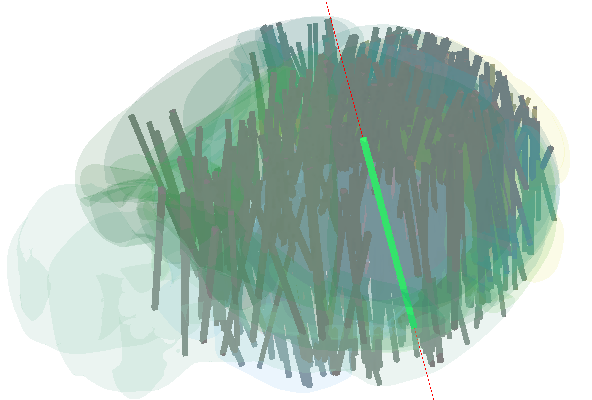|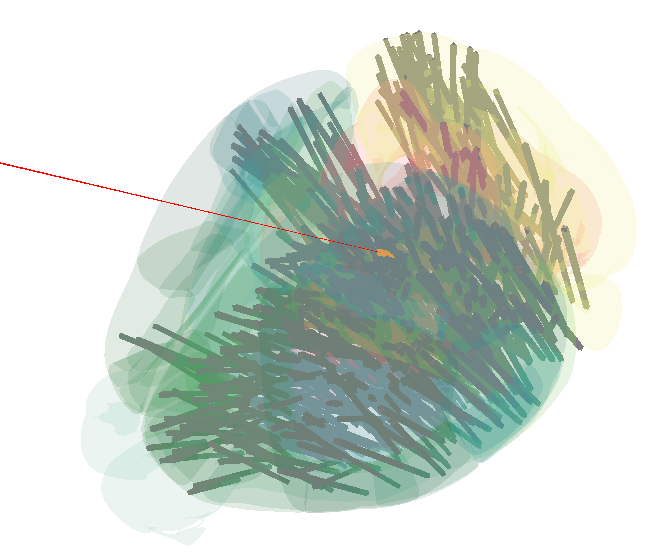|
|---|---|
|cde63527-7f5a-4cc3-8ac2-215d82e7da26|bb099402-fb31-4cfd-824e-1c97530a0875|

In [ ]:
# IBL kernel: configure a new dataset and inspect available raw AP files.
from pathlib import Path, PurePosixPath
from datetime import datetime
import json
import re

from one.api import ONE

ROOT = Path('G:/academic')
CACHE_DIR = ROOT / 'ONE'
CACHE_DIR.mkdir(parents=True, exist_ok=True)
one = ONE(base_url='https://openalyx.internationalbrainlab.org', cache_dir=CACHE_DIR, mode='remote')

# Edit these values for a new dataset.
NEW_EID = 'bb099402-fb31-4cfd-824e-1c97530a0875'
NEW_PID = None
NEW_PROBE = 'probe00'

# Optional run label. Leave as None to auto-generate from EID/probe/time.
RUN_LABEL = None
RUN_ROOT = ROOT / 'week8_kilosort4_runs'
RUN_ROOT.mkdir(parents=True, exist_ok=True)

if NEW_EID is None:
    if not NEW_PID:
        raise ValueError('Set NEW_EID, or set NEW_PID and leave NEW_EID = None.')
    NEW_EID, probe_from_pid = one.pid2eid(NEW_PID)
    if NEW_PROBE is None:
        NEW_PROBE = probe_from_pid

NEW_EID = str(NEW_EID)
NEW_PROBE = str(NEW_PROBE)
run_stamp = datetime.now().strftime('%Y%m%d_%H%M%S')
eid_short = NEW_EID.split('-')[0]
run_label = RUN_LABEL or f'{eid_short}_{NEW_PROBE}_{run_stamp}'
RUN_DIR = RUN_ROOT / run_label

print('NEW_EID:', NEW_EID)
print('NEW_PID:', NEW_PID)
print('NEW_PROBE:', NEW_PROBE)
print('RUN_DIR:', RUN_DIR)

datasets_new = one.list_datasets(NEW_EID, details=True, query_type='remote', keep_eid_index=True)
rel_new = datasets_new['rel_path'].astype(str)
raw_ap_rows_new = datasets_new.loc[
    rel_new.str.contains(rf'^raw_ephys_data/{re.escape(NEW_PROBE)}/', regex=True)
    & rel_new.str.contains(r'\.ap\.(?:cbin|bin|meta|ch)$', regex=True),
    ['rel_path', 'file_size']
].copy()
raw_ap_rows_new['file_size_GB'] = raw_ap_rows_new['file_size'] / 1e9

if raw_ap_rows_new.empty:
    display(datasets_new[['rel_path', 'file_size']].head(30))
    raise RuntimeError(f'No raw AP files found for {NEW_EID} / {NEW_PROBE}. Check NEW_PROBE or choose another EID/PID.')

display(raw_ap_rows_new.sort_values('rel_path'))


### IBL kernel: download and decompress raw AP

This cell resumes existing complete or partial downloads where possible. It decompresses the selected `.ap.cbin` into `.ap.bin` in the normal ONE cache. The Kilosort output is still saved separately in `RUN_DIR`.


In [ ]:
# IBL kernel: download selected probe raw AP files and decompress .ap.cbin to .ap.bin.
from pathlib import Path, PurePosixPath
import json

RUN_NEW_RAW_DOWNLOAD = True
RUN_NEW_CBIN_DECOMPRESS = True


def expected_local_path_new(rel_path):
    rel_path = PurePosixPath(str(rel_path))
    hits = sorted(CACHE_DIR.glob(f'**/{rel_path.as_posix()}'))
    if hits:
        return hits[0]
    return CACHE_DIR / rel_path


def file_status_new(path, expected_size=None):
    path = Path(path)
    if not path.exists():
        return {'path': str(path), 'status': 'missing', 'size': 0, 'expected_size': expected_size}
    size = path.stat().st_size
    if expected_size and size == int(expected_size):
        status = 'complete'
    elif expected_size and size < int(expected_size):
        status = 'partial'
    elif expected_size and size > int(expected_size):
        status = 'size_mismatch_large'
    else:
        status = 'exists_unverified'
    return {'path': str(path), 'status': status, 'size': size, 'expected_size': expected_size}


def load_rel_path_new(eid, rel_path):
    rel_path = PurePosixPath(str(rel_path))
    return Path(one.load_dataset(
        eid,
        rel_path.name,
        collection=str(rel_path.parent),
        query_type='remote',
        download_only=True,
    ))


def ensure_dataset_downloaded_new(eid, row):
    rel_path = str(row['rel_path'])
    expected_size = int(row['file_size']) if row.get('file_size') else None
    target = expected_local_path_new(rel_path)
    before = file_status_new(target, expected_size)

    if before['status'] == 'complete':
        print('already complete:', target)
        return {**before, 'rel_path': rel_path, 'action': 'skipped_complete'}

    if before['status'] == 'partial':
        print('partial file found; continuing download/check:', target, before['size'], '/', expected_size)
    elif before['status'] == 'missing':
        print('missing file; starting download:', rel_path)
    else:
        print('existing file needs verification/redownload:', before)

    path = load_rel_path_new(eid, rel_path)
    after = file_status_new(path, expected_size)
    if after['status'] != 'complete':
        print('warning: file is still not complete after download attempt:', after)
    else:
        print('complete:', path)
    return {**after, 'rel_path': rel_path, 'action': 'downloaded_or_resumed', 'before': before}


download_records_new = []
if RUN_NEW_RAW_DOWNLOAD:
    for _, row in raw_ap_rows_new.sort_values('rel_path').iterrows():
        download_records_new.append(ensure_dataset_downloaded_new(NEW_EID, row))
else:
    print('RUN_NEW_RAW_DOWNLOAD is False; checking local cache only.')
    for _, row in raw_ap_rows_new.sort_values('rel_path').iterrows():
        target = expected_local_path_new(row['rel_path'])
        download_records_new.append({**file_status_new(target, int(row['file_size'])), 'rel_path': str(row['rel_path']), 'action': 'checked_only'})

def local_paths_for_current_raw_rows(extension):
    paths = []
    for _, row in raw_ap_rows_new.sort_values('rel_path').iterrows():
        rel_path = str(row['rel_path'])
        if rel_path.endswith(extension):
            status = file_status_new(expected_local_path_new(rel_path), int(row['file_size']))
            if status['status'] in {'complete', 'exists_unverified'}:
                paths.append(Path(status['path']))
            else:
                matching_records = [record for record in download_records_new if record['rel_path'] == rel_path]
                paths.extend(Path(record['path']) for record in matching_records if Path(record['path']).exists())
    return sorted(set(paths))

local_cbin_candidates = local_paths_for_current_raw_rows('.ap.cbin')
print('local .ap.cbin candidates for current EID/probe:', local_cbin_candidates)

AP_BIN_NEW = None
decompress_record_new = {'action': 'not_requested', 'ap_bin': None}
if RUN_NEW_CBIN_DECOMPRESS:
    if not local_cbin_candidates:
        raise FileNotFoundError('No local .ap.cbin found for the current EID/probe. Set RUN_NEW_RAW_DOWNLOAD=True first.')
    import spikeglx
    cbin = local_cbin_candidates[0]
    reader = spikeglx.Reader(cbin)
    target_bin = cbin.with_suffix('.bin')
    expected_bin_size = int(reader.ns * reader.nc * reader.dtype.itemsize)
    before_bin = file_status_new(target_bin, expected_bin_size)

    if before_bin['status'] == 'complete':
        AP_BIN_NEW = target_bin
        decompress_record_new = {**before_bin, 'action': 'skipped_complete'}
        print('decompressed .ap.bin already complete:', AP_BIN_NEW)
    else:
        print('decompressing/resuming by overwriting incomplete target:', target_bin)
        reader.decompress_file(keep_original=True, out=target_bin, overwrite=True)
        after_bin = file_status_new(target_bin, expected_bin_size)
        if after_bin['status'] != 'complete':
            raise RuntimeError(f'Decompressed .ap.bin is not complete: {after_bin}')
        AP_BIN_NEW = target_bin
        decompress_record_new = {**after_bin, 'action': 'decompressed'}
        print('decompressed .ap.bin complete:', AP_BIN_NEW)
else:
    local_bin_candidates = [path.with_suffix('.bin') for path in local_paths_for_current_raw_rows('.ap.cbin') if path.with_suffix('.bin').exists()]
    if local_bin_candidates:
        AP_BIN_NEW = local_bin_candidates[0]
        print('using existing .ap.bin for current EID/probe:', AP_BIN_NEW)
    else:
        print('RUN_NEW_CBIN_DECOMPRESS is False and no .ap.bin was found for the current EID/probe.')

RUN_DIR.mkdir(parents=True, exist_ok=True)
run_info = {
    'eid': NEW_EID,
    'pid': NEW_PID,
    'probe': NEW_PROBE,
    'run_label': run_label,
    'run_dir': str(RUN_DIR),
    'ap_bin': str(AP_BIN_NEW) if AP_BIN_NEW else None,
    'download_records': download_records_new,
    'decompress_record': decompress_record_new,
}
run_info_path = RUN_DIR / 'run_info_download.json'
run_info_path.write_text(json.dumps(run_info, indent=2), encoding='utf-8')
print('saved download/decompress run info:', run_info_path)


### Kilosort4 kernel: run sorting into a new output folder

Switch to the Kilosort4 kernel before running this cell. It reads `RUN_DIR/run_info_download.json`, creates a separate `kilosort4` subfolder, and refuses to run if that output folder already contains files unless `ALLOW_KS_OVERWRITE = True`.


Memory note: this cell uses low-memory Kilosort4 defaults. The previous `(32000000, 10, 6)` allocation came from `n_spikes x nearest_chans x n_pcs`; reducing `nearest_chans` and `n_pcs` is the direct control for that memory use.


In [ ]:
# Kilosort4 kernel: run Kilosort4 for the configured EID/probe without overwriting older results.
from pathlib import Path
import json
import re

ROOT = Path('G:/academic')
RUN_ROOT = ROOT / 'week8_kilosort4_runs'

# If you restarted the notebook or changed kernels, set this to the run folder printed by the IBL cell.
# Example: RUN_DIR = Path('G:/academic/week8_kilosort4_runs/e5c75b62_probe00_20260701_120000')
try:
    RUN_DIR
except NameError:
    RUN_DIR = None

RUN_NEW_KILOSORT4 = True
ALLOW_KS_OVERWRITE = True

# Low-memory defaults. The large array is approximately
# n_spikes * nearest_chans * n_pcs * 4 bytes, before extra temporary copies.
KS_NEAREST_CHANS = 2
KS_N_PCS = 2
SAVE_EXTRA_VARS = False
CLEAR_CACHE = True


if RUN_DIR is None:
    candidates = sorted(RUN_ROOT.glob('*'), key=lambda p: p.stat().st_mtime, reverse=True)
    if not candidates:
        raise FileNotFoundError('No run folders found. Run the IBL setup/download cells first, or set RUN_DIR manually.')
    RUN_DIR = candidates[0]
    print('RUN_DIR was not set; using latest run folder:', RUN_DIR)
else:
    RUN_DIR = Path(RUN_DIR)

run_info_path = RUN_DIR / 'run_info_download.json'
if not run_info_path.exists():
    raise FileNotFoundError(f'Missing run info file: {run_info_path}')
run_info = json.loads(run_info_path.read_text(encoding='utf-8'))
AP_BIN_NEW = Path(run_info['ap_bin'])
NEW_PROBE = run_info['probe']
NEW_EID = run_info['eid']
RESULTS_DIR_NEW = RUN_DIR / 'kilosort4'

if not AP_BIN_NEW.exists():
    raise FileNotFoundError(f'AP bin not found: {AP_BIN_NEW}')


def read_spikeglx_meta(meta_path):
    meta = {}
    for line in Path(meta_path).read_text(errors='ignore').splitlines():
        if '=' in line:
            key, value = line.split('=', 1)
            meta[key.strip()] = value.strip()
    return meta


def infer_kilosort_settings_from_bin(ap_bin):
    meta_candidates = [ap_bin.with_suffix('.meta'), Path(str(ap_bin).replace('.ap.bin', '.ap.meta'))]
    meta_path = next((p for p in meta_candidates if p.exists()), None)
    n_chan_bin = 385
    fs = 30000
    if meta_path is not None:
        meta = read_spikeglx_meta(meta_path)
        n_chan_bin = int(meta.get('nSavedChans', n_chan_bin))
        fs_text = meta.get('imSampRate') or meta.get('niSampRate')
        if fs_text is not None:
            fs = float(fs_text)
    return {
        'filename': ap_bin,
        'n_chan_bin': n_chan_bin,
        'fs': fs,
        'nearest_chans': KS_NEAREST_CHANS,
        'n_pcs': KS_N_PCS,
    }

def estimate_feature_memory_gib(n_spikes, nearest_chans=KS_NEAREST_CHANS, n_pcs=KS_N_PCS):
    return int(n_spikes) * int(nearest_chans) * int(n_pcs) * 4 / 1024**3


if RESULTS_DIR_NEW.exists() and any(RESULTS_DIR_NEW.iterdir()) and not ALLOW_KS_OVERWRITE:
    raise FileExistsError(f'Kilosort output folder already contains files: {RESULTS_DIR_NEW}. Use a new RUN_LABEL/RUN_DIR or set ALLOW_KS_OVERWRITE=True.')

if RUN_NEW_KILOSORT4:
    from kilosort import run_kilosort
    RESULTS_DIR_NEW.mkdir(parents=True, exist_ok=True)
    settings = infer_kilosort_settings_from_bin(AP_BIN_NEW)
    print('Low-memory Kilosort settings:', settings)
    print('Feature memory estimate for 32M spikes:', f'{estimate_feature_memory_gib(32_000_000):.2f} GiB')
    print('SAVE_EXTRA_VARS:', SAVE_EXTRA_VARS)
    print('Kilosort output directory:', RESULTS_DIR_NEW)
    ks_output_new = run_kilosort(
        settings=settings,
        probe_name='NeuroPix1_default.mat',
        results_dir=RESULTS_DIR_NEW,
        data_dtype='int16',
        save_extra_vars=SAVE_EXTRA_VARS,
        clear_cache=CLEAR_CACHE,
        verbose_console=True,
    )
    run_info['kilosort_results_dir'] = str(RESULTS_DIR_NEW)
    run_info['kilosort_settings'] = {k: str(v) for k, v in settings.items()}
    run_info['save_extra_vars'] = SAVE_EXTRA_VARS
    run_info['clear_cache'] = CLEAR_CACHE
    run_info['feature_memory_estimate_32m_spikes_gib'] = estimate_feature_memory_gib(32_000_000)
    (RUN_DIR / 'run_info_kilosort4.json').write_text(json.dumps(run_info, indent=2), encoding='utf-8')
    print('saved Kilosort4 run info:', RUN_DIR / 'run_info_kilosort4.json')
else:
    print('RUN_NEW_KILOSORT4 is False. Set it to True to run Kilosort4 for:', AP_BIN_NEW)


2026-07-05 01:37:42,549 kilosort.run_kilosort INFO     Kilosort version 4.1.7
2026-07-05 01:37:42,566 kilosort.run_kilosort INFO     Python version 3.11.15
2026-07-05 01:37:42,566 kilosort.run_kilosort INFO     ----------------------------------------
2026-07-05 01:37:42,570 kilosort.run_kilosort INFO     System information:
2026-07-05 01:37:42,574 kilosort.run_kilosort INFO     Windows-10-10.0.26200-SP0 AMD64
2026-07-05 01:37:42,577 kilosort.run_kilosort INFO     Intel64 Family 6 Model 186 Stepping 2, GenuineIntel
2026-07-05 01:37:42,597 kilosort.run_kilosort INFO     Using GPU for PyTorch computations. Specify `device` to change this.


Low-memory Kilosort settings: {'filename': WindowsPath('G:/academic/ONE/churchlandlab_ucla/Subjects/UCLA017/2021-11-16/002/raw_ephys_data/probe00/_spikeglx_ephysData_g0_t0.imec.ap.bin'), 'n_chan_bin': 385, 'fs': 30000.0, 'nearest_chans': 2, 'n_pcs': 2}
Feature memory estimate for 32M spikes: 0.48 GiB
SAVE_EXTRA_VARS: False
Kilosort output directory: G:\academic\week8_kilosort4_runs\bb099402_probe00_20260702_202008\kilosort4


2026-07-05 01:37:42,656 kilosort.run_kilosort INFO     Using CUDA device: NVIDIA GeForce RTX 2050 4.00GB
2026-07-05 01:37:42,656 kilosort.run_kilosort INFO     ----------------------------------------
2026-07-05 01:37:42,669 kilosort.run_kilosort INFO     Sorting [WindowsPath('G:/academic/ONE/churchlandlab_ucla/Subjects/UCLA017/2021-11-16/002/raw_ephys_data/probe00/_spikeglx_ephysData_g0_t0.imec.ap.bin')]
2026-07-05 01:37:42,671 kilosort.run_kilosort INFO     clear_cache=True
2026-07-05 01:37:42,680 kilosort.run_kilosort DEBUG    Initial ops:

ops = {
    'n_chan_bin': 385,
    'fs': 30000.0,
    'batch_size': 60000,
    'nblocks': 1,
    'Th_universal': 9,
    'Th_learned': 8,
    'tmin': 0,
    'tmax': inf,
    'nt': 61,
    'shift': None,
    'scale': None,
    'batch_downsampling': 1,
    'artifact_threshold': inf,
    'nskip': 25,
    'whitening_range': 32,
    'highpass_cutoff': 300,
    'binning_depth': 5,
    'sig_interp': 20,
    'drift_smoothing': [0.5, 0.5, 0.5],
    'nt0min